In [2]:
import pandas as pd
import numpy as np
import warnings
import sys
import joblib
from cuml.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

train_bc = pd.read_parquet('train_bc.parquet')
test_bc = pd.read_parquet('test_bc.parquet')


X_train = train_bc.drop('Attack', axis=1)
y_train = train_bc['Attack']
X_test = test_bc.drop('Attack', axis=1)
y_test = test_bc['Attack']

In [ ]:
print(f"Train data loaded: {len(X_train)} samples.")
print(f"Test data loaded: {len(X_test)} samples.")
print("-" * 30)


pipe = Pipeline([
    ('svm', SVC( 
        random_state=42,
        
    ))
])


param_grid = [
    {
        'svm__kernel': ['linear'],
        'svm__C': [0.1, 1, 10]
    },
    {
        'svm__kernel': ['rbf'],
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 0.1, 1]
    }
]





Train data loaded: 509488 samples.
Test data loaded: 371272 samples.
------------------------------


In [ ]:
total_combinations = 12

grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1',
    verbose=0,
    n_jobs=-1
)

print(f"Starting Grid Search across {total_combinations} total parameter combinations for cuML SVC...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")


Starting Grid Search across 12 total parameter combinations for cuML SVC...
⚠️ Training individual models will be accelerated by the GPU.
Grid Search complete.


In [ ]:

best_svm = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n" + "="*50)
print("CUML SVM HYPERPARAMETER TUNING RESULTS (GPU)")
print(f"Best cross-validation F1 score: {best_score:.4f}")
print(f"Best parameters found: {best_params}")
print("="*50)

joblib.dump(best_svm, r'binary_svm.joblib')
print(f"Best model saved to binary_svm_gpu.joblib")

y_pred = best_svm.predict(X_test)
y_pred_train = best_svm.predict(X_train)


✨ CUML SVM HYPERPARAMETER TUNING RESULTS (GPU) ✨
Best cross-validation F1 score: 0.8575
Best parameters found: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Best model saved to binary_svm_gpu.joblib


In [ ]:
test_accuracy = accuracy_score(y_test, y_pred)
test_f1 = f1_score(y_test, y_pred)

print("\n--- FINAL MODEL PERFORMANCE ON TEST SET ---")
print(f"Best Kernel: {best_params.get('svm__kernel', 'N/A')}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")
print(f"Test Set F1-Score: {test_f1:.4f}")


print("\nClassification Report (Test Set):\n")
print(classification_report(y_test, y_pred))
print("-" * 50)
print("Script execution finished.")

print("\nClassification Report (Train Set):\n")
print(classification_report(y_train, y_pred_train))
print("-" * 50)
print("Script execution finished.")


--- FINAL MODEL PERFORMANCE ON TEST SET ---
Best Kernel: linear
Test Set Accuracy: 0.9672
Test Set F1-Score: 0.9677

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.98      0.95      0.97    185636
           1       0.95      0.98      0.97    185636

    accuracy                           0.97    371272
   macro avg       0.97      0.97      0.97    371272
weighted avg       0.97      0.97      0.97    371272

--------------------------------------------------
Script execution finished.

Classification Report (Train Set):

              precision    recall  f1-score   support

           0       0.97      0.93      0.95    254744
           1       0.93      0.97      0.95    254744

    accuracy                           0.95    509488
   macro avg       0.95      0.95      0.95    509488
weighted avg       0.95      0.95      0.95    509488

--------------------------------------------------
Script execution finished.


In [ ]:
def plot_classification_report(y_true, y_pred, title):
    """Plot classification report heatmap with support shown as plain numbers per row."""

    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df = pd.DataFrame(report_dict).transpose()

    support = df['support'].fillna(0).astype(int)

    drop_rows = ['accuracy', 'macro avg', 'weighted avg', 'micro avg']
    df = df.drop(drop_rows, errors='ignore')

    df_metrics = df.drop(columns=['support'], errors='ignore').astype(float)

    plt.figure(figsize=(8, 4))
    ax = sns.heatmap(
        df_metrics,
        annot=True,
        cmap="YlGnBu",
        fmt=".3f",
        linewidths=.5,
        linecolor='black',
        cbar=True
    )

    plt.subplots_adjust(right=0.88)

    for y, cls in enumerate(df_metrics.index):
        sup_val = support.loc[cls]
        ax.text(
            df_metrics.shape[1] + 0.6,
            y + 0.5,
            str(sup_val),
            va='center',
            ha='left',
            fontsize=10,
            color='black'
        )

    ax.text(
        df_metrics.shape[1] + 0.6,
        -0.2,
        "support",
        va='bottom',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

    plt.title(f"Classification Report Heatmap ({title})")
    plt.ylabel("Class")
    plt.xlabel("Metrics")
    plt.tight_layout()

    # Save the plot
    out_path =  f"classification_report_{title.split()[0]}.png"
    plt.savefig(out_path)
    print(f"Saved {title} plot to: {out_path}")
    plt.show()


GENERATING CLASSIFICATION REPORT PLOTS
Saved Train Set - SVM plot to: classification_report_Train.png


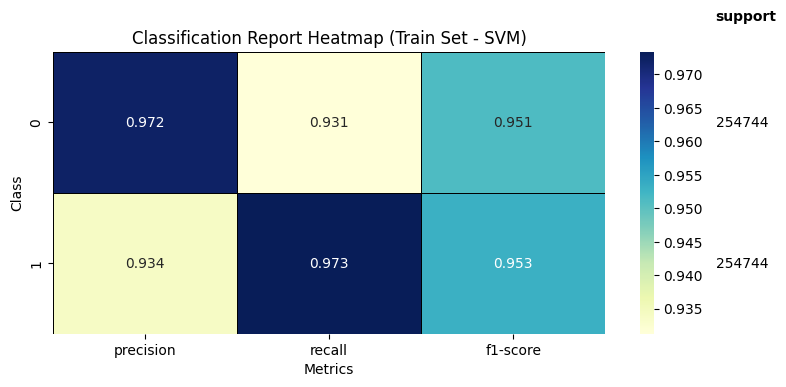

Saved Test Set - SVM plot to: classification_report_Test.png


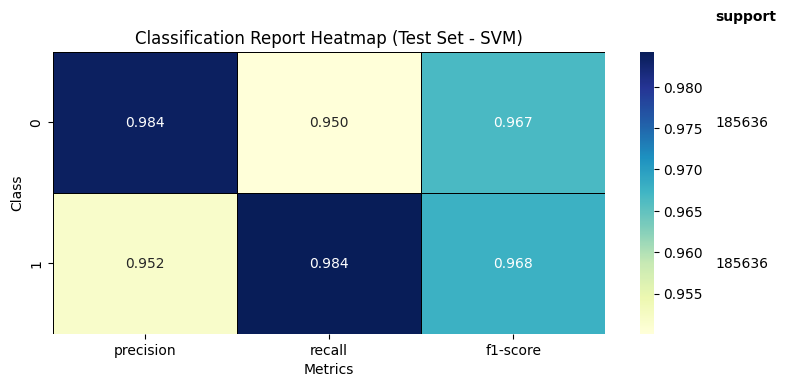

In [ ]:

print("\n" + "="*50)
print("GENERATING CLASSIFICATION REPORT PLOTS")
print("="*50)

plot_classification_report(
    y_train,
    y_pred_train,
    'Train Set - SVM',
)


plot_classification_report(
    y_test,
    y_pred,
    'Test Set - SVM',
)